## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("TensorFlow", tf.__version__, "| GPU:", gpus)


TensorFlow 2.10.1 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.10.1


## 2. Loading and explore the dataset

Categories: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


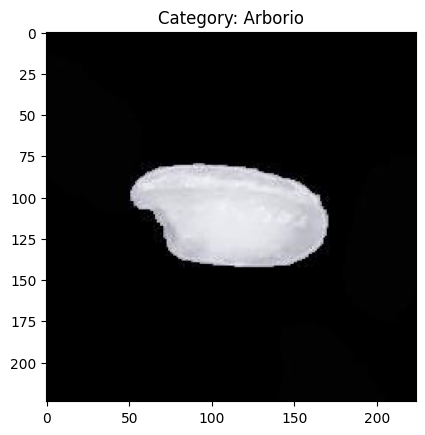

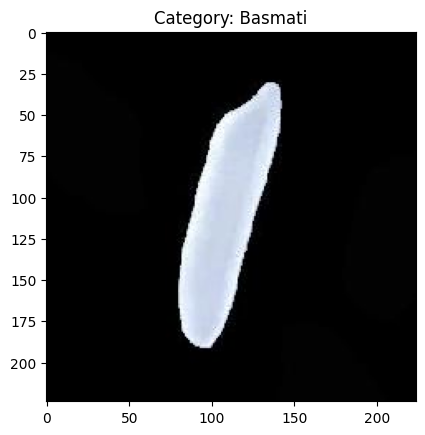

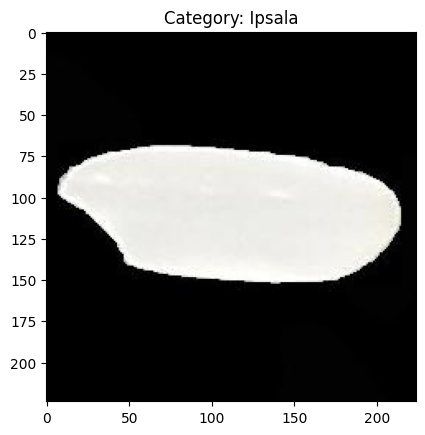

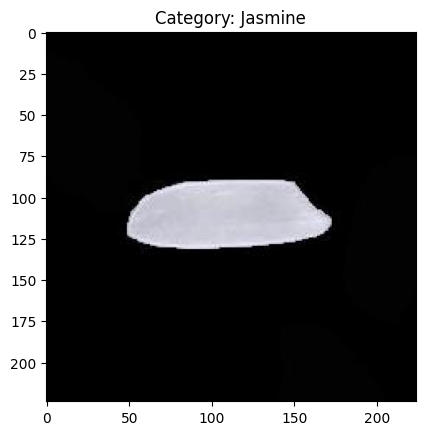

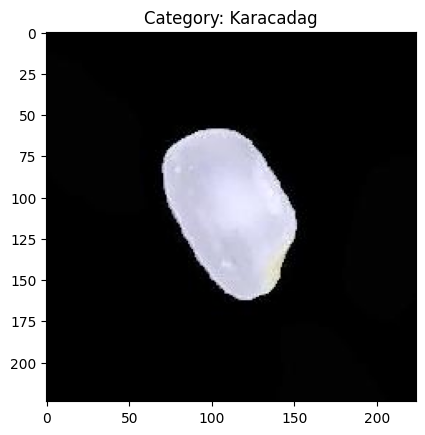

In [5]:
import os
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Define the dataset path
dataset_path = r"D:\Rice_DL_Project\Rice_Classification\data\raw\Rice_Image_Dataset"  

# Explore the dataset
categories = [category for category in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, category))]
print("Categories:", categories)

# Visualize some sample images from each category
for category in categories:
    category_path = os.path.join(dataset_path, category)
    sample_image = os.listdir(category_path)[0]  # Pick one image from each category
    img = image.load_img(os.path.join(category_path, sample_image), target_size=(224, 224))
    plt.imshow(img)
    plt.title(f"Category: {category}")
    plt.show()

### Data quality check

Check class balance, corrupt files, image size/mode and duplicate files (MD5). Duplicates are removed before splitting to avoid train/test leakage.

In [ ]:
from PIL import Image
import hashlib

rows = []
for category in sorted(categories):
    folder = os.path.join(dataset_path, category)
    for fname in sorted(os.listdir(folder)):
        path = os.path.join(folder, fname)
        try:
            with Image.open(path) as im:
                im.verify()                      # detect corrupt files
            with Image.open(path) as im:
                size, mode = im.size, im.mode
            with open(path, "rb") as f:
                md5 = hashlib.md5(f.read()).hexdigest()
            rows.append((path, category, size, mode, md5))
        except Exception as e:
            print("Corrupt:", path, e)

info = pd.DataFrame(rows, columns=["filepath", "label", "size", "mode", "md5"])
print("Images per class:\n", info["label"].value_counts(), "\n")
print("Image sizes:\n", info["size"].value_counts(), "\n")
print("Color modes:\n", info["mode"].value_counts(), "\n")
print("Duplicate files:", info["md5"].duplicated().sum())
print("Duplicate groups with conflicting labels:", (info.groupby("md5")["label"].nunique() > 1).sum())

# Drop conflicting-label groups, then keep one copy of each duplicate
conflict = info.groupby("md5")["label"].transform("nunique") > 1
clean_df = info[~conflict].drop_duplicates("md5").reset_index(drop=True)
print(f"Kept {len(clean_df)} of {len(info)} images")

## 3. Data Preprocessing

Split 70/15/15 (stratified by class). Val/test are not shuffled so predictions stay aligned with labels.

In [ ]:
# Use the cleaned (filepath, label) table from the data quality check
df = clean_df[["filepath", "label"]]

# Split 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

datagen = ImageDataGenerator(rescale=1./255)

def make_generator(data, shuffle):
    return datagen.flow_from_dataframe(
        data,
        x_col="filepath",
        y_col="label",
        target_size=(224, 224),
        batch_size=32,
        class_mode="categorical",
        shuffle=shuffle,
    )

train_generator = make_generator(train_df, shuffle=True)
validation_generator = make_generator(val_df, shuffle=False)
test_generator = make_generator(test_df, shuffle=False)

## 4. CNN model

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Initialize the CNN model
model = Sequential()

# Input layer (added explicitly)
model.add(Input(shape=(224, 224, 3)))

# First convolutional layer
model.add(Conv2D(32, (3, 3), activation='relu'))  
model.add(MaxPooling2D(pool_size=(2, 2)))  

# Second convolutional layer
model.add(Conv2D(64, (3, 3), activation='relu'))  
model.add(MaxPooling2D(pool_size=(2, 2)))  

# Third convolutional layer
model.add(Conv2D(128, (3, 3), activation='relu')) 
model.add(MaxPooling2D(pool_size=(2, 2)))  

# Flatten the 2D feature maps into 1D
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))

# Add a Dropout layer to prevent overfitting
model.add(Dropout(0.5))

# Output layer (5 classes for classification)
model.add(Dense(5, activation='softmax'))

## 5. Compiling the CNN Model

In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 26, 26, 128)      0

## 6. Model Training

Train once and save to disk. If a saved model exists it is loaded instead of retraining (set `FORCE_RETRAIN = True` to retrain).

In [ ]:
import json

FORCE_RETRAIN = False
models_dir = r"D:\Rice_DL_Project\Rice_Classification\models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "model1_cnn.h5")
history_path = os.path.join(models_dir, "model1_cnn_history.json")

if os.path.exists(model_path) and os.path.exists(history_path) and not FORCE_RETRAIN:
    # Reuse the saved model and its training history
    model = tf.keras.models.load_model(model_path, compile=False)
    with open(history_path) as f:
        history_dict = json.load(f)
    print("Loaded saved model:", model_path)
else:
    history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator,
    )
    history_dict = history.history
    model.save(model_path, include_optimizer=False)
    with open(history_path, "w") as f:
        json.dump(history_dict, f)
    print("Trained and saved model to:", model_path)

print("Epochs:", len(history_dict["loss"]))
print("Final epoch:", {k: round(v[-1], 4) for k, v in history_dict.items()})

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history_dict['accuracy'])
plt.plot(history_dict['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history_dict['loss'])
plt.plot(history_dict['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## 7. Model Evaluation

Evaluated on the held-out test set. Precision, recall and F1 are macro-averaged.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

class_names = list(test_generator.class_indices.keys())
y_pred = np.argmax(model.predict(test_generator), axis=1)
y_true = test_generator.classes

print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

## 8. Model Prediction

In [ ]:
X_test, y_test = test_generator.next() 
predictions = model.predict(X_test)

def plot_predictions(X_test, y_test, predictions, class_indices):
    plt.figure(figsize=(12, 12))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_test[i])
        true_label = np.argmax(y_test[i])
        predicted_label = np.argmax(predictions[i])
        true_class = list(class_indices.keys())[list(class_indices.values()).index(true_label)]
        predicted_class = list(class_indices.keys())[list(class_indices.values()).index(predicted_label)]
        plt.title(f"True: {true_class}\nPredicted: {predicted_class}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_predictions(X_test, y_test, predictions, test_generator.class_indices)